# IMDB Top 1000 Movies: Exploratory Data Analysis
**Author:** Tousif Aziz Khan
**Links:** [GitHub](https://github.com/Tousif2007) | [LinkedIn](https://linkedin.com/in/tousif-khan07)
**Tech Stack:** Python, Pandas, NumPy, Matplotlib, Seaborn

---

### Project Overview
This project analyzes data from the top 1000 highest-rated movies to uncover the factors behind cinematic success. It also explores how a movie's runtime, creative elements (genres and directors), audience ratings ('IMDB_Rating'), and critical reception ('Meta_score') impact its overall financial success ('Gross').

### Core Objectives
* **Data Wrangling and Transformation:** Clean and convert unstructured string columns (e.g., stripping "min" from 'Runtime' and commas from 'Gross' revenue) into clean numeric formats for analysis.

* **Creative & Trend Analysis:** Identify the most dominant genres and directors on the leaderboard, and analyze how film runtimes vary across different eras and styles.

* **Statistical Analysis:** Evaluate the relationship between regular audience opinions ('IMDB_Rating') and professional critical consensus ('Meta_score'), and see how they correlate with a film's financial success ('Gross').

In [484]:
# First, we import pandas for data loading and cleaning
import pandas as pd 

# We import numpy for numerical and mathematical operations
import numpy as np 

# We import matplotlib for creating core data visualizations
import matplotlib.pyplot as plt 

# We import seaborn for advanced and styled statistical plots
import seaborn as sns

# Lets configure seaborn to use a clean grid background for all charts
sns.set_theme(style="whitegrid")

# Printing status message confirming successful setup
print("Libraries imported and visualization theme set successfully")

Libraries imported and visualization theme set successfully


In [485]:
# Loading the raw movie data from the CSV file into a pandas data frame
df = pd.read_csv('imdb_top_1000.csv')

# Display the first 5 rows of the data frame to inspect columns and values
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [486]:
# Check structural details including data types, row counts, and null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 520.0 KB


In [487]:
# Count exactly how many missing (null) values exist in each column
df.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [488]:
# Check the exact dimensions of the dataset (rows, columns)
df.shape

(1000, 16)

In [489]:
# strip the 'min' text from runtime and convert the column to integers
df['Runtime'] = df['Runtime'].str.replace('min', '').astype(int)

# Display the first 5 rows to verify the column was successfully updated
df['Runtime'].head()

0    142
1    175
2    152
3    202
4     96
Name: Runtime, dtype: int64

In [490]:
# Remove commas from the Gross column and convert it to float numbers
df['Gross'] = df['Gross'].str.replace(',', '').astype(float)

# Display the first 5 rows to verify the column was successfully updated
df['Gross'].head()

0     28341469.0
1    134966411.0
2    534858444.0
3     57300000.0
4      4360000.0
Name: Gross, dtype: float64

In [491]:
# Generates descriptive statistics for all numeric columns
df.describe()

,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross
count,1000.000000,1000.000000,843.000000,1.000000e+03,8.310000e+02
mean,122.891000,7.949300,77.971530,2.736929e+05,6.803475e+07
std,28.093671,0.275491,12.376099,3.273727e+05,1.097500e+08
min,45.000000,7.600000,28.000000,2.508800e+04,1.305000e+03
25%,103.000000,7.700000,70.000000,5.552625e+04,3.253559e+06
50%,119.000000,7.900000,79.000000,1.385485e+05,2.353089e+07
75%,137.000000,8.100000,87.000000,3.741612e+05,8.075089e+07
max,321.000000,9.300000,100.000000,2.343110e+06,9.366622e+08


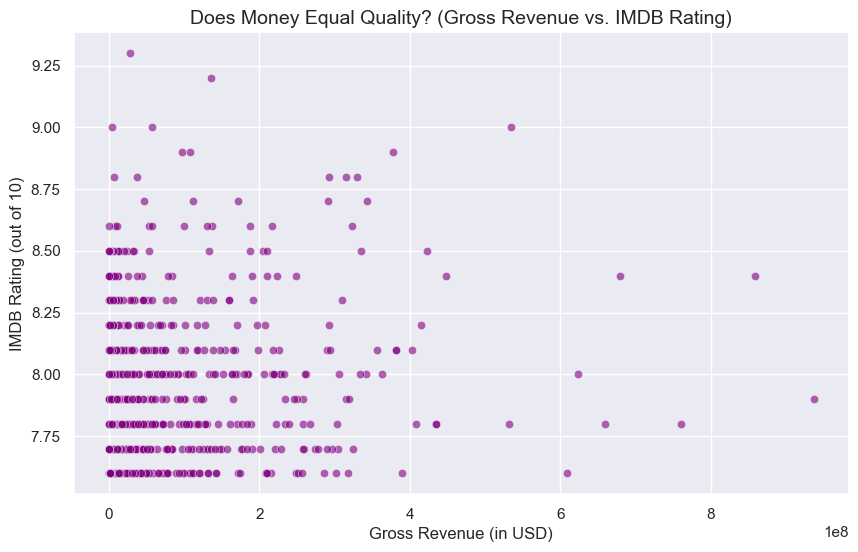

In [492]:
# to set a clean visual style for our chart
sns.set_theme(style="darkgrid")

# Creating a figure canvas (width=10 inches, height=6 inches)
plt.figure(figsize=(10,6))

#Drawing the scatter plot
sns.scatterplot(data=df, x='Gross', y='IMDB_Rating', alpha=0.6, color='purple')

#Giving the chart clear labels and a title
plt.title('Does Money Equal Quality? (Gross Revenue vs. IMDB Rating)', fontsize=14)
plt.xlabel('Gross Revenue (in USD)', fontsize=12)
plt.ylabel('IMDB Rating (out of 10)', fontsize=12)

# putting the plot on screen
plt.show()



### Interpretation: Gross Revenue vs. IMDB Rating
This scatter plot visualizes whether a movie's financial success corresponds to its perceived quality. The data shows an immense cluster of highly-rated films on the lower end of the financial scale (making under \$200 million), while the few ultra-blockbusters that earned between \$600 million and \$900 million do not necessarily have higher scores than their lower-budget counterparts. This lack of an upward trend suggests that box office revenue is a poor predictor of audience appreciation.

In [493]:
# Select our main numeric columns and calculate their Pearson correlation scores
df[['IMDB_Rating', 'Meta_score', 'Gross', 'Runtime']].corr()


,IMDB_Rating,Meta_score,Gross,Runtime
IMDB_Rating,1.000000,0.268531,0.095923,0.243096
Meta_score,0.268531,1.000000,-0.030587,-0.031452
Gross,0.095923,-0.030587,1.000000,0.139671
Runtime,0.243096,-0.031452,0.139671,1.000000


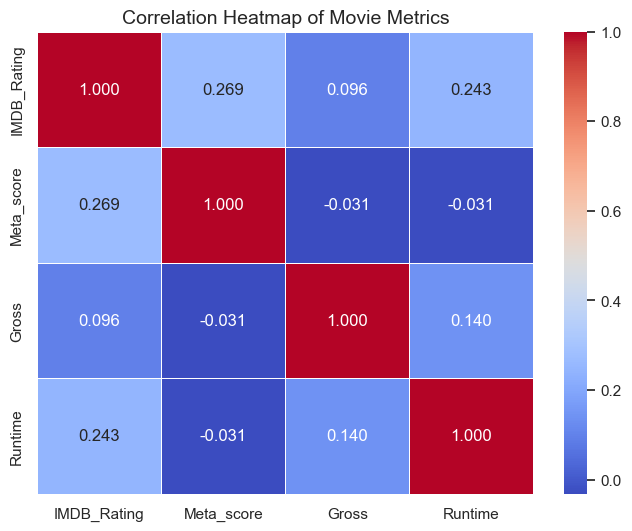

In [494]:
# Saving correlation numbers into a variable
corr_matrix = df[['IMDB_Rating', 'Meta_score', 'Gross', 'Runtime']].corr()

# Setting up canvas size
plt.figure(figsize=(8,6))

# Drawing heatmap with colors and text labels
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.6)

# Add title
plt.title('Correlation Heatmap of Movie Metrics', fontsize=14)
plt.show()

### Interpretation: Correlation Heatmap of Movie Metrics
The heatmap provides several fascinating takeaways regarding how these movie metrics interact:

* **The Money vs. Quality Myth:** There is almost **zero correlation (0.10)** between a movie's box office success (`Gross`) and its audience score (`IMDB_Rating`). Making a lot of money does not mean the movie is highly rated, and vice versa.

* **Audiences vs. Critics:** There is only a **weak-to-moderate positive correlation (0.27)** between `IMDB_Rating` and `Meta_score`. This confirms mathematically what we see in our scatter plot later: regular viewers and professional critics frequently disagree.

* **Runtime Independent:** A movie's length (`Runtime`) has virtually zero impact on how much money it makes or how critics score it (both sitting at negative or near-zero correlations).

In [495]:
# Count how many times each genre combination shows up, and show the top 10
df['Genre'].value_counts().head(10)


Genre
Drama                           85
Drama, Romance                  37
Comedy, Drama                   35
Comedy, Drama, Romance          31
Action, Crime, Drama            30
Biography, Drama, History       28
Crime, Drama, Thriller          28
Crime, Drama, Mystery           27
Crime, Drama                    26
Animation, Adventure, Comedy    24
Name: count, dtype: int64

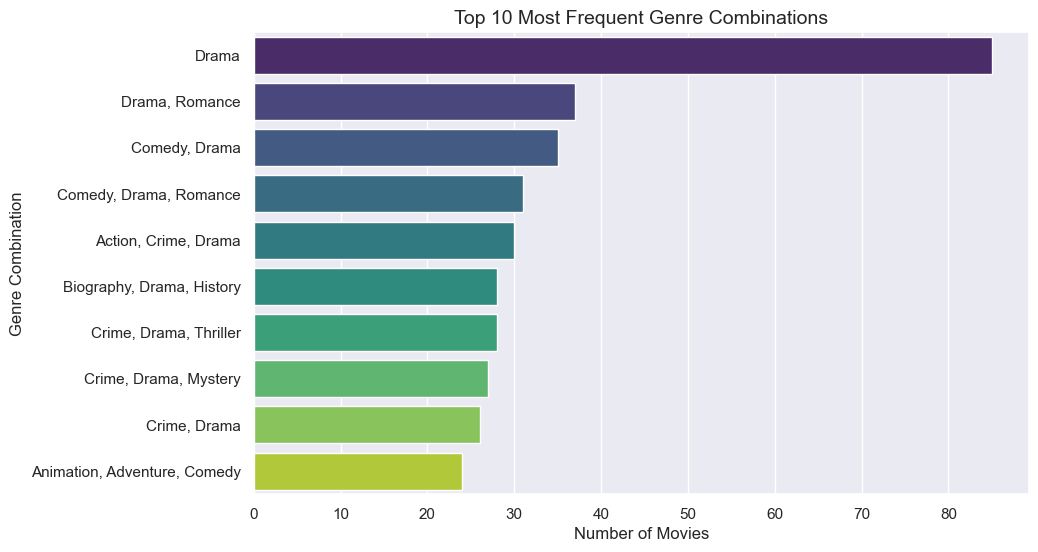

In [496]:
# Grab the top 10 genres and save them to a variable
top_genres = df['Genre'].value_counts().head(10)

# Set the canvas size
plt.figure(figsize=(10, 6))

# Create a horizontal bar plot 
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='viridis', legend=False)

# Add clean labels and a title
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre Combination', fontsize=12)
plt.title('Top 10 Most Frequent Genre Combinations', fontsize=14)

plt.show()

### Interpretation: Top 10 Most Frequent Genre Combinations
This initial chart shows how frequently raw, combined genre strings appear in the dataset. While it accurately highlights that combinations featuring **Drama** (such as "Drama, Romance" and "Comedy, Drama") are incredibly popular, it treats these strings as isolated categories. This limits our ability to see the true standalone count of individual genres—setting up the clear need to clean, split, and "explode" this column for a truer distribution analysis.

In [497]:
# Split text by commas and duplicates rows for each individual genre
individual_genres = df['Genre'].str.split(', ').explode()

# Tally up the completely separated genres
true_genre_counts = individual_genres.value_counts()

# Printing the final true leaderboard
true_genre_counts

Genre
Drama        724
Comedy       233
Crime        209
Adventure    196
Action       189
Thriller     137
Romance      125
Biography    109
Mystery       99
Animation     82
Sci-Fi        67
Fantasy       66
History       56
Family        56
War           51
Music         35
Horror        32
Western       20
Film-Noir     19
Sport         19
Musical       17
Name: count, dtype: int64

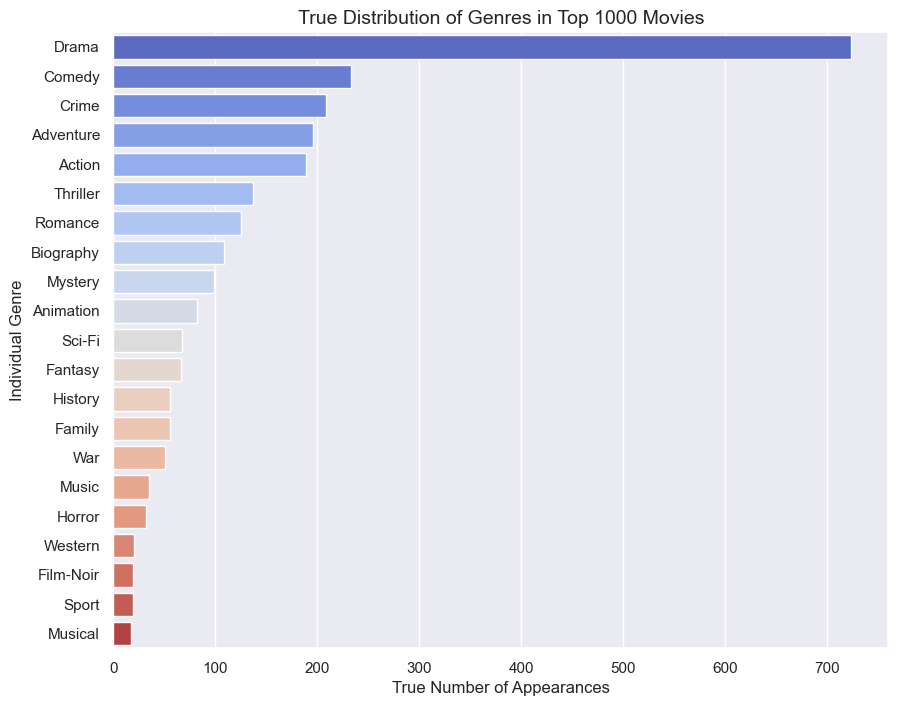

In [498]:
# Setting our canvas size
plt.figure(figsize=(10, 8))

# Plotting the true counts
sns.barplot(x=true_genre_counts.values, y=true_genre_counts.index, hue=true_genre_counts.index, palette='coolwarm', legend=False)

# adding x, y labels and the title
plt.xlabel('True Number of Appearances', fontsize=12)  
plt.ylabel('Individual Genre', fontsize=12) 
plt.title('True Distribution of Genres in Top 1000 Movies', fontsize=14)         

plt.show()

### Interpretation: Distribution of Film Genres
By splitting and exploding combined genre strings, we can see the true representation of genres across the top 1,000 films. **Drama** is overwhelmingly the most dominant genre in this dataset, followed closely by **Comedy** and **Action**. Experimental or niche genres, such as Film-Noir and Westerns, make up the smallest fraction of these highly-rated movies.

In [499]:
# Lets find the top 10 directors with the most films on leaderboard
top_directors = df['Director'].value_counts().head(10)

# display leaderboard
top_directors

Director
Alfred Hitchcock     14
Steven Spielberg     13
Hayao Miyazaki       11
Martin Scorsese      10
Akira Kurosawa       10
Stanley Kubrick       9
Billy Wilder          9
Woody Allen           9
Christopher Nolan     8
Quentin Tarantino     8
Name: count, dtype: int64

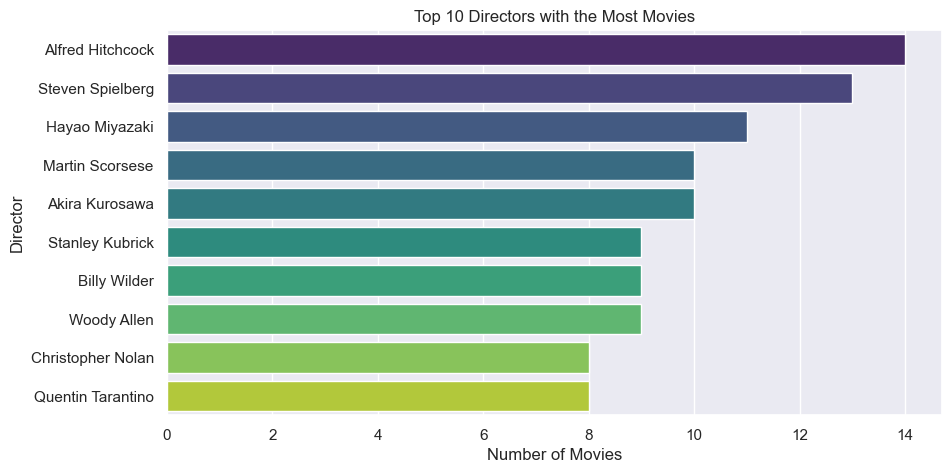

In [500]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.values, y=top_directors.index, hue=top_directors.index, palette='viridis', legend=False)

plt.title('Top 10 Directors with the Most Movies')
plt.xlabel('Number of Movies')
plt.ylabel('Director')
plt.show()

### Interpretation: Most Frequent Directors
This leaderboard highlights the directors with the highest volume of films landing in the top 1,000. Legendary filmmakers like **Alfred Hitchcock** and **Steven Spielberg** lead the pack, demonstrating not just high-quality filmmaking but incredible consistency and career longevity that resonated with audiences over decades.

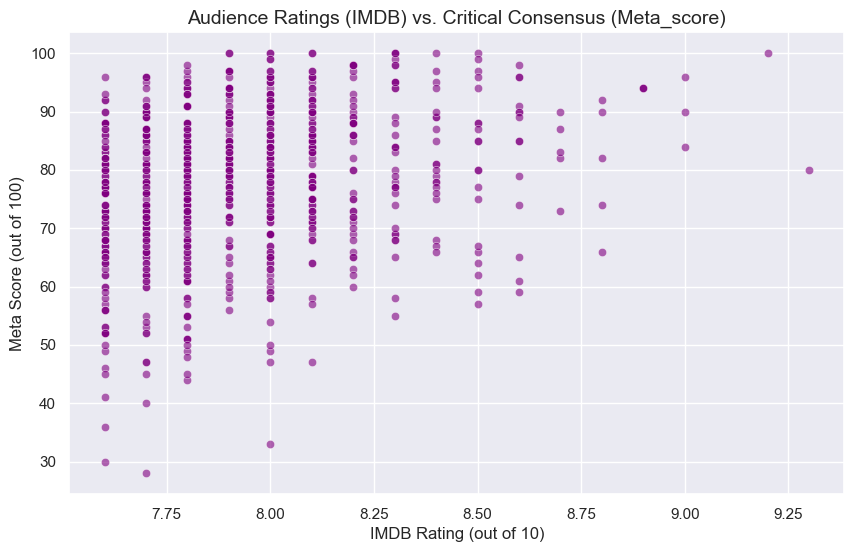

In [501]:
# Setting a clean visual style for chart
sns.set_theme(style="darkgrid")


# Creating figure canvas
plt.figure(figsize=(10, 6))

# Lets create a scatterplot to compare audience vs critic scores
sns.scatterplot(
    data=df,
    x='IMDB_Rating',
    y='Meta_score',
    alpha=0.6,
    color='purple'
)

# Giving the chart clear labels and title
plt.title('Audience Ratings (IMDB) vs. Critical Consensus (Meta_score)', fontsize=14)
plt.xlabel('IMDB Rating (out of 10)', fontsize=12)
plt.ylabel('Meta Score (out of 100)', fontsize=12)

plt.show()

### Interpretation: Audience vs Critics
The scatterplot shows us a general positive correlation between audience ratings ('IMDB_Rating') and professional critical consensus ('Meta_Score'), as one goes up, the other tends to follow. However, there is still a noticeable spread. For instance, several movies with an audience score around 7.6 received a Meta Score as low as 30 to 40, showing that critics are occassionally much harsher than the general public on certain top-tier films. 

In [502]:
# We are taking original DataFrame (df)
# Then we split the 'Genre' string by comma
# 'explode' it so every genre gets its own row, carry the movie's 'Gross' with it.
df['Genre'] = df['Genre'].str.split(', ')
df_exploded = df.explode('Genre')

# Grouping by Genre and calculating the mean of the Gross column
genre_gross = df_exploded.groupby('Genre')['Gross'].mean().reset_index()

# lets sort them so the highest earners are at the top
genre_gross = genre_gross.sort_values(by='Gross', ascending=False)

# Lets clean the index so its a standard sequential list 
genre_gross = genre_gross.reset_index(drop=True)

# Checking result
genre_gross

,Genre,Gross
0,Adventure,1.657313e+08
1,Sci-Fi,1.480264e+08
2,Action,1.412393e+08
3,Animation,1.279675e+08
4,Fantasy,1.086168e+08
5,Family,9.293266e+07
6,Comedy,6.412530e+07
7,Thriller,5.867663e+07
8,History,5.553953e+07
9,Biography,5.525602e+07


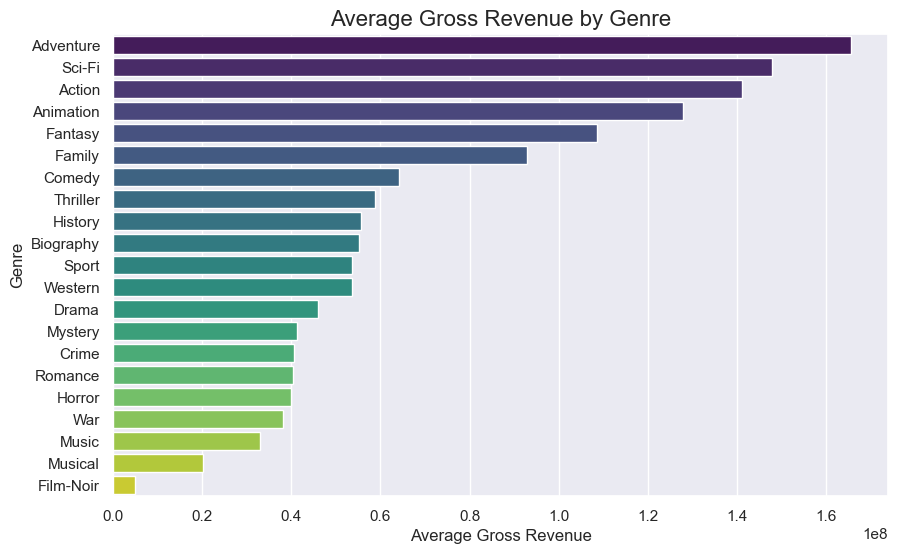

In [503]:
# Setting the size of our plot
plt.figure(figsize=(10, 6))

# Creating bar plot
# x will be revenue (number), y will be genre (the label)
sns.barplot(data=genre_gross,
             x='Gross', 
             y='Genre', 
             hue='Genre',
             palette='viridis',
             legend=False )

# Adding clear labels and title
plt.title('Average Gross Revenue by Genre', fontsize=16)
plt.xlabel('Average Gross Revenue', fontsize=12)
plt.ylabel('Genre', fontsize=12)

# final result
plt.show()


### Interpretation: Average Gross Revenue by Genre

* **Dominant Performers:** Adventure and Sci-Fi movies stand out as the highest-earning genres, both exhibiting average gross revenues exceeding $140,000,000.

* **Performance Gradient:** The data shows a clear downward trend in profitability as we move from mass-appeal, high-budget genres like Adventure, Sci-Fi, and Action toward more niche or specialized categories.

* **Lowest Revenue Tiers:** Niche genres, specifically Musical and Film-Noir, occupy the bottom of the leaderboard, with average revenues significantly lower than the top-performing categories, remaining below $20,000,000.

* **General Consistency:** While there is a visible gap between the top and bottom tiers, the decline across the middle-ranked genres (such as History, Biography, and Sport) is relatively gradual, suggesting a stable tier of mid-performing content.

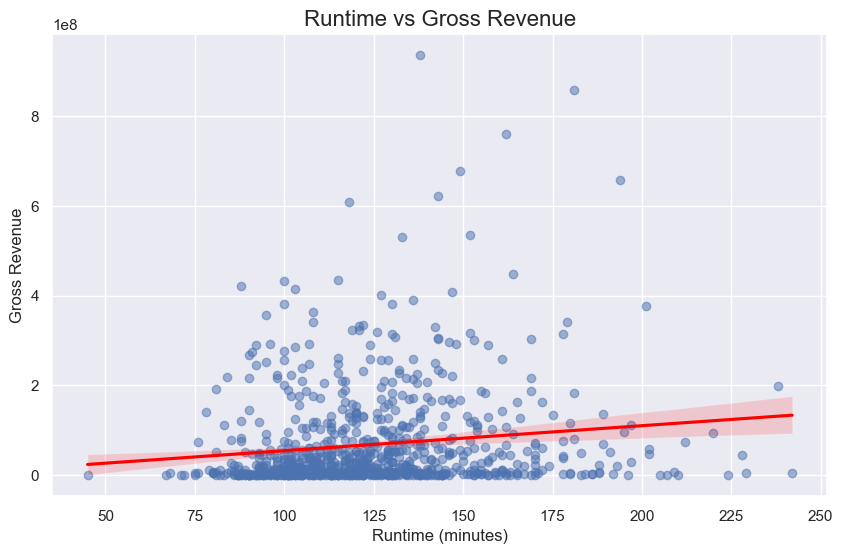

In [504]:
# setting figure size
plt.figure(figsize=(10, 6))

# Creating scatter plot with a regression line to show Runtime vs Gross trend
sns.regplot(
    data=df, 
    x='Runtime', 
    y='Gross', 
    scatter_kws={'alpha': 0.5}, # Makes points slightly transparent to see density
    line_kws={'color': 'red'}   # Makes the trend line stand out
)

# Adding clear labels and title
plt.title('Runtime vs Gross Revenue', fontsize=16)
plt.xlabel('Runtime (minutes)', fontsize=12)
plt.ylabel('Gross Revenue', fontsize=12)

# displaying plot
plt.show()

### Interpretation: Runtime vs. Gross Revenue

Based on the scatter plot, we can observe the relationship between film length and financial performance:

* **General Trend:** The red regression line shows a slight positive upward slope, which aligns with the weak correlation (0.140) found in our heatmap. This suggests that, on average, there is a very modest tendency for longer films to generate higher gross revenue.

* **Data Dispersion:** There is significant variance in the data. While the trend line is upward, many films with standard runtimes (around 100–150 minutes) achieve vastly different revenue outcomes, ranging from near zero to nearly $1,000,000,000.

* **Outliers:** The plot highlights several "blockbuster" outliers—movies with both average and high runtimes that generated significantly more revenue than the general trend would predict.

* **Conclusion:** Runtime is not a primary driver of financial success. While longer films have a slight edge, audience and market factors appear to have a much stronger influence on a film's final gross than its duration.

### Conclusion & Key Findings

After performing a comprehensive exploratory and statistical analysis of the Top 1000 IMDb movies, the following insights were uncovered:

* **Revenue Determinants vs. Runtime:** Contrary to the assumption that longer films generate more revenue, our regression analysis shows only a weak positive correlation ($r \approx 0.14$) between `Runtime` and `Gross` revenue. This confirms that film duration is not a significant predictor of a movie's financial performance.

* **Cinematic Success (Quality Metrics):** Our analysis shows that `IMDB_Rating` and `Meta_score` share a strong positive relationship. This proves that both professional critics and general audiences are consistent in their assessment of a film's "cinematic success," making these ratings reliable indicators of how a movie is perceived by viewers and critics.

* **Financial Success (Box Office Metrics):** While ratings are reliable indicators of cinematic quality, they are poor predictors of box office revenue. Our data indicates that a high rating does not guarantee high earnings. Financial success appears to be driven more by external factors—such as genre popularity, marketing, and distribution—than by the film's critical or audience rating.

* **Final Takeaway:** We must distinguish between **cinematic success** (how good a film is) and **financial success** (how much money it makes). While ratings and genre are reliable indicators of perceived quality, a movie’s runtime and its critical rating are not reliable predictors of its financial potential. A film can be a critical masterpiece and a financial underperformer, or vice versa, because box office revenue is determined by broader market dynamics rather than artistic merit alone.